In [72]:
import os
from fredapi import Fred 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


In [93]:
#connect api key
fred = Fred(api_key=os.environ["FRED_API_KEY"])

#get indicators:
def get_macro_data(indicators):
    df = pd.DataFrame()
    for name, key in indicators.items():
        df[name] = fred.get_series(key)
    return df



In [ ]:
indicators = {"CPI": "CPIAUCSL",
              "INDPRO": "INDPRO",
              "TERM_SPREAD":"T10Y3M",
              "FED_RATE":"FEDFUNDS",
              "HY_OAS": "BAMLH0A0HYM2",
              "VIX": "VIXCLS",
              "liquidity": "NFCI"}
#check what month data i am looking at

df = get_macro_data(indicators)

In [95]:
start = "2010-12-01"
end = "2026-01-31"
df = df.loc[start:end]

In [96]:
df.head()

,CPI,INDPRO,TERM_SPREAD,FED_RATE,HY_OAS,VIX,liquidity
2010-12-01,220.472,93.6787,2.81,0.18,6.02,21.36,NaN
2011-01-01,221.187,93.4814,NaN,0.17,NaN,NaN,NaN
2011-02-01,221.898,93.1102,3.33,0.16,4.99,17.63,NaN
2011-03-01,223.046,94.0788,3.27,0.14,4.76,21.01,NaN
2011-04-01,224.093,93.7749,3.39,0.10,4.72,17.40,-0.5596


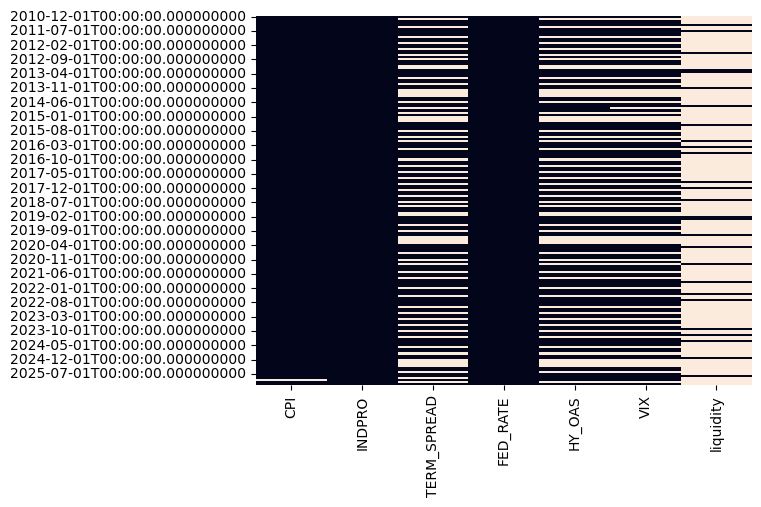

In [97]:
#find out missingness
sns.heatmap(df.isna(), cbar=False)
plt.show()

we can see that most of the monthly macros like CPI, INDPRO are regularly observed whereeas the daily market info has some days that they are not availabel due to bank holidays etc

In [98]:
df.isna().sum()/len(df)

CPI            0.005525
INDPRO         0.000000
TERM_SPREAD    0.353591
FED_RATE       0.000000
HY_OAS         0.342541
VIX            0.348066
liquidity      0.850829
dtype: float64

removing liquidity data since most of it is missing

In [99]:
df.drop(columns="liquidity", inplace=True)

In [100]:
df

,CPI,INDPRO,TERM_SPREAD,FED_RATE,HY_OAS,VIX
2010-12-01,220.472,93.6787,2.81,0.18,6.02,21.36
2011-01-01,221.187,93.4814,NaN,0.17,NaN,NaN
2011-02-01,221.898,93.1102,3.33,0.16,4.99,17.63
2011-03-01,223.046,94.0788,3.27,0.14,4.76,21.01
2011-04-01,224.093,93.7749,3.39,0.10,4.72,17.40
...,...,...,...,...,...,...
2025-08-01,323.364,101.5867,-0.12,4.33,3.13,20.38
2025-09-01,324.368,101.7779,NaN,4.22,2.84,16.12
2025-10-01,NaN,101.5163,0.11,4.09,2.81,16.29
2025-11-01,325.031,101.9528,NaN,3.88,NaN,NaN


In [101]:
df.shape

(181, 6)

In [102]:
#collapsing the df into monthly df -- \
#keeping the last observed value of a month and then shifting (introducing lag)

df = df.resample("M").last()

/var/folders/m4/kpnsdh9d0r79tkyhpw0nck1w0000gn/T/ipykernel_9887/1908255616.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample("M").last()


In [103]:
df.shape

(181, 6)

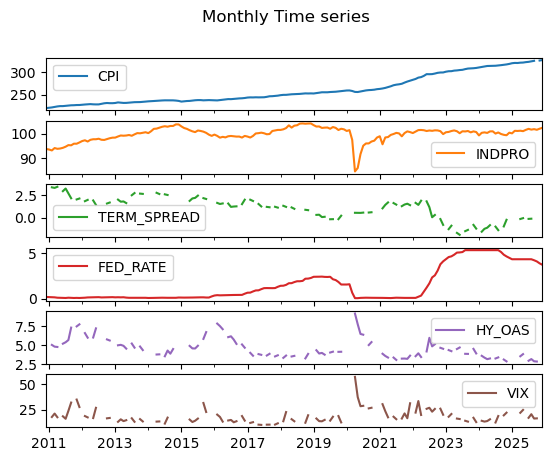

In [104]:
#plotting time seires and acf pltos to see how to fill missing info
df[df.columns].plot(subplots=True, title="Monthly Time series")
plt.show()

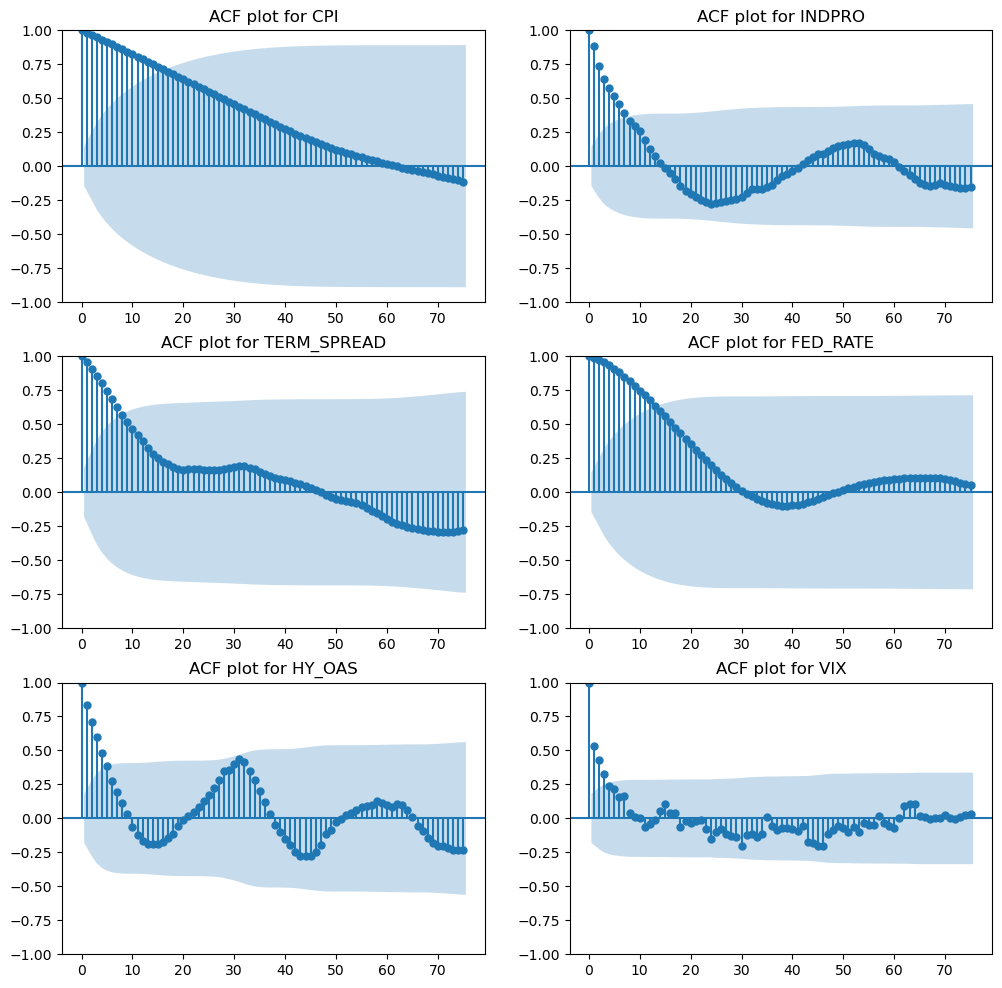

In [105]:
fig, axes = plt.subplots(3,2, figsize=(12,12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    plot_acf(df[col].dropna(), ax=axes[i], lags=75)
    axes[i].set_title(f"ACF plot for {col}")
plt.show()

based on these plots chose forward fill to replace NaNs to preserve regime related behavior

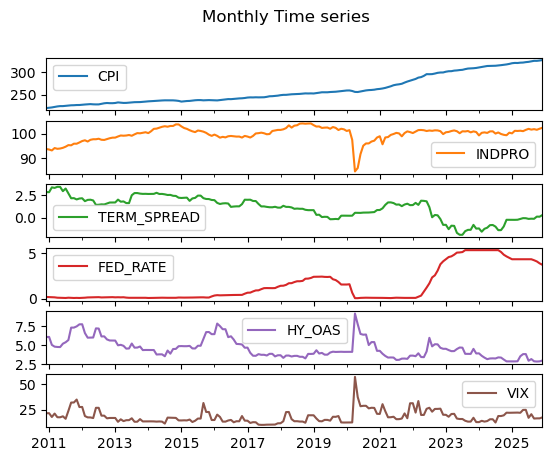

In [106]:
df_raw = df.copy()

df = df.ffill()
#got this code from chatgpt to add noise to each variable that has been forward filled:
rng = np.random.default_rng(seed=42)
missing_mask = df_raw.isna()
# noise scale: very small relative to each column's variability
noise_frac = 0.01  # 1% of column std

df_noisy = df.copy()

for col in df.columns:
    std = df[col].std()
    if std == 0 or np.isnan(std):
        continue

    noise = rng.normal(
        loc=0.0,
        scale=noise_frac * std,
        size=df.shape[0]
    )

    # add noise ONLY where forward-fill occurred
    df_noisy.loc[missing_mask[col], col] += noise[missing_mask[col]]
df= df_noisy
#plotting time seires and acf pltos to see how to fill missing info
df[df.columns].plot(subplots=True, title="Monthly Time series")
plt.show()

In [107]:
df.columns

Index(['CPI', 'INDPRO', 'TERM_SPREAD', 'FED_RATE', 'HY_OAS', 'VIX'], dtype='object')

In [ ]:
#feature engineering:

#Quarterly growth for CPI and Industrial production:
for col in ["CPI", "INDPRO"]:
    df[f"{col}_q"] = df[col].pct_change(3)

#monthly changes:
#decide if pct change makes sense here. (maybe diff)
#include s&p500
for col in ["TERM_SPREAD","FED_RATE", "HY_OAS", "VIX"]:
    df[f"{col}_m"] = df[col].pct_change(1)

#lag data:
df_lagged = df.shift(1).dropna()

#need to scale and standardize data


In [109]:
df_lagged

,CPI,INDPRO,TERM_SPREAD,FED_RATE,HY_OAS,VIX,CPI_q,INDPRO_q,TERM_SPREAD_m,FED_RATE_m,HY_OAS_m,VIX_m
2011-04-30,223.046000,94.0788,3.270000,0.14,4.760000,21.010000,0.011675,0.004271,-0.018018,-0.125000,-0.046092,0.191719
2011-05-31,224.093000,93.7749,3.390000,0.10,4.720000,17.400000,0.013138,0.003140,0.036697,-0.285714,-0.008403,-0.171823
2011-06-30,224.806000,93.8880,3.379828,0.09,4.705846,17.352771,0.013105,0.008354,-0.003001,-0.100000,-0.002999,-0.002714
2011-07-31,224.806000,94.1720,2.910000,0.09,5.150000,18.300000,0.007891,0.000991,-0.139009,0.000000,0.094383,0.054587
2011-08-31,225.395000,94.6360,3.200000,0.07,5.340000,15.870000,0.005810,0.009183,0.099656,-0.222222,0.036893,-0.132787
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,322.132000,101.8940,-0.140000,4.33,2.910000,16.830000,0.005654,0.007576,1.100051,0.000000,-0.231390,-0.318352
2025-09-30,323.364000,101.5867,-0.120000,4.33,3.130000,20.380000,0.008684,0.006153,-0.142857,0.000000,0.075601,0.210933
2025-10-31,324.368000,101.7779,-0.129730,4.22,2.840000,16.120000,0.008921,0.002950,0.081087,-0.025404,-0.092652,-0.209028
2025-11-30,324.330696,101.5163,0.110000,4.09,2.810000,16.290000,0.006825,-0.003707,-1.847912,-0.030806,-0.010563,0.010546


In [110]:
# add z scores
def rolling_z_scores(x, lag):
    mu = x.rolling(lag).mean()
    sd = x.rolling(lag).std()
    return (x-mu)/sd

rolling_period = 24
for col in df.columns:
    df[f"{col}_z"] = rolling_z_scores(df[col], rolling_period)

In [ ]:
#add regime flags

#curve inversion:
df["curve_inv"] = (df["TERM_SPREAD"] < 0).astype(int)

#vol:
#got this code from chatgpt
df["high_vol"] = (df["VIX"] > df["VIX"].rolling(24).quantile(0.9)).astype(int)

#credit:
df["credit_spread"] = (df["HY_OAS"] > df["HY_OAS"].rolling(24).quantile(0.9)).astype(int)




In [125]:
# add interaction terms

#check for interaction:
sp500 = fred.get_series("SP500")
sp500_ret = sp500.pct_change()
sp500 = sp500_ret.resample("M").last()
start = "2016-01-01"
end = "2026-01-31"
df_new = df.loc[start:end]

/var/folders/m4/kpnsdh9d0r79tkyhpw0nck1w0000gn/T/ipykernel_9887/2023040984.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sp500_ret = sp500.pct_change()
/var/folders/m4/kpnsdh9d0r79tkyhpw0nck1w0000gn/T/ipykernel_9887/2023040984.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sp500 = sp500_ret.resample("M").last()


In [126]:
print(sp500.shape)
print(df_new.shape)

(120,)
(120, 27)


In [122]:
df_new

,CPI,INDPRO,TERM_SPREAD,FED_RATE,HY_OAS,VIX,CPI_q,INDPRO_q,TERM_SPREAD_m,FED_RATE_m,...,VIX_z,CPI_q_z,INDPRO_q_z,TERM_SPREAD_m_z,FED_RATE_m_z,HY_OAS_m_z,VIX_m_z,curve_inv,high_vol,credit_spread
2016-01-31,237.652000,99.5607,1.921685,0.34,6.403145,14.653927,-0.000341,-0.007049,-0.009441,0.416667,...,-0.291727,-0.411356,-0.537472,0.018657,1.440035,-0.225590,-0.114325,0,0,0
2016-02-29,237.336000,99.0445,1.620000,0.38,7.790000,19.980000,-0.002861,-0.004876,-0.156990,0.117647,...,0.882533,-0.855459,-0.301077,-2.008047,0.118484,1.977129,1.224493,0,0,1
2016-03-31,238.080000,98.3096,1.500000,0.36,7.460000,17.700000,0.001342,-0.007392,-0.074074,-0.052632,...,0.313617,0.050008,-0.470110,-0.762110,-0.584813,-0.725627,-0.577821,0,0,1
2016-04-30,238.992000,98.6421,1.560000,0.37,7.050000,13.100000,0.005638,-0.009227,0.040000,0.027778,...,-0.761925,0.943569,-0.586389,0.863618,-0.218784,-0.938377,-1.064512,0,0,0
2016-05-31,239.557000,98.4184,1.581287,0.37,7.048090,13.082233,0.009358,-0.006321,0.013646,0.000000,...,-0.763475,1.622788,-0.209774,0.451289,-0.339106,-0.335565,-0.106663,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,323.364000,101.5867,-0.120000,4.33,3.130000,20.380000,0.008684,0.006153,-0.142857,0.000000,...,0.631240,0.599187,0.623189,-0.311262,0.486852,0.861948,1.075844,1,0,0
2025-09-30,324.368000,101.7779,-0.129730,4.22,2.840000,16.120000,0.008921,0.002950,0.081087,-0.025404,...,-0.432450,0.728875,0.249218,0.267590,-0.900274,-0.899257,-1.324695,1,0,0
2025-10-31,324.330696,101.5163,0.110000,4.09,2.810000,16.290000,0.006825,-0.003707,-1.847912,-0.030806,...,-0.435077,0.028106,-0.630003,-3.314174,-1.109091,-0.023841,-0.072496,0,0,0
2025-11-30,325.031000,101.9528,0.099779,3.88,2.830080,16.296936,0.005155,0.003604,-0.092919,-0.051345,...,-0.426318,-0.563342,0.313332,-0.019094,-1.952833,0.260339,-0.065775,0,0,0


Text(0.5, 1.0, 'Interaction between VIX and yield curve')

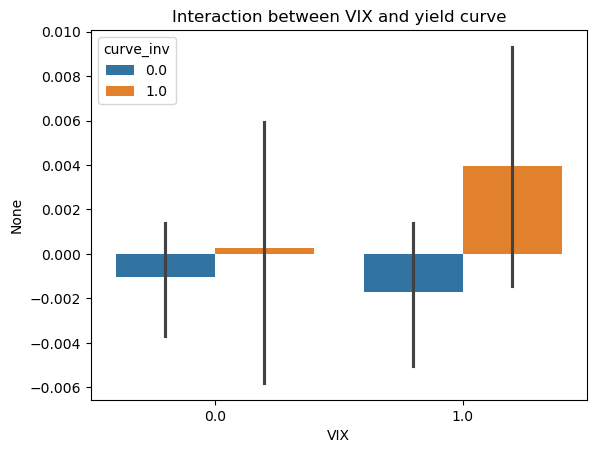

In [128]:
#checking interactive between VIX and curve inversion
sns.barplot(data=df_new, x=(df_new["VIX"] > (df_new["VIX"].median())).astype(int), y=sp500_ret, hue="curve_inv")
plt.title("Interaction between VIX and yield curve")

there is a lot of errors but we can conclude that is some interaction.

Text(0.5, 1.0, 'Interaction between credit spread and growth curve')

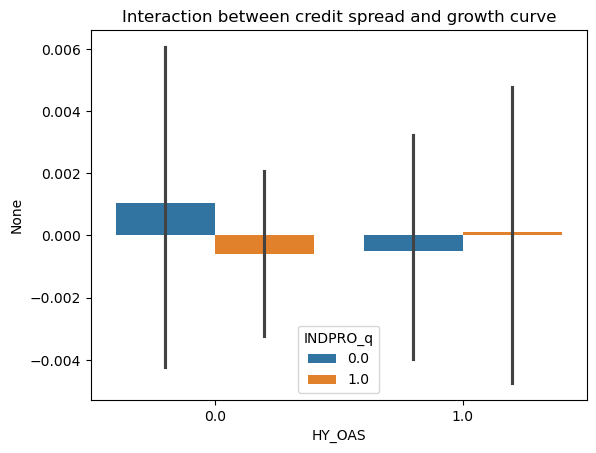

In [133]:
#checking interactive between VIX and curve inversion
sns.barplot(data=df_new, x=(df_new["HY_OAS"] > (df_new["HY_OAS"].median())).astype(int), y=sp500_ret,\
             hue=(df_new["INDPRO_q"] > (df_new["INDPRO_q"].median())).astype(int))
plt.title("Interaction between credit spread and growth curve")

discuss ^^ (maybe worth exploring linear regression)

In [ ]:
start = "2016-12-01"
end = "2026-01-31"
df = df.loc[start:end]